In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../../../Modules")

from utils import create_grid, process_latin
enc = 'utf-8'

random.seed(0)
np.random.seed(0)

In [2]:
GID0 = 'CM'
GID2_NAME = 'Benoue'
GID2 = 'CMR.7.1_1'

In [3]:
cameroon_gid3_gdf = gpd.read_file(f"../../../../Shapefiles/Cameroon Shapefiles/gadm41_CMR_3.shp",  encoding=enc)

In [4]:
cameroon_gid3_gdf.head()

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
0,CMR.1.1.1_1,CMR,Cameroon,CMR.1_1,Adamaoua,NA,CMR.1.1_1,Djerem,NA,Ngaoundal,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((12.88791 6.00037, 12.87870 6.00037, ..."
1,CMR.1.1.2_1,CMR,Cameroon,CMR.1_1,Adamaoua,NA,CMR.1.1_1,Djerem,NA,Tibati,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((12.95229 6.80165, 12.95230 6.80158, ..."
2,CMR.1.2.1_1,CMR,Cameroon,CMR.1_1,Adamaoua,NA,CMR.1.2_1,Faro et Déo,NA,Galim Tignère,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((12.67353 7.01145, 12.67273 7.01130, ..."
3,CMR.1.2.2_1,CMR,Cameroon,CMR.1_1,Adamaoua,NA,CMR.1.2_1,Faro et Déo,NA,Mayo Baléo,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((12.30252 7.37010, 12.30241 7.37009, ..."
4,CMR.1.2.3_1,CMR,Cameroon,CMR.1_1,Adamaoua,NA,CMR.1.2_1,Faro et Déo,NA,Tignère,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((12.87665 6.97192, 12.87537 6.97309, ..."


In [5]:
print(f'CRS: {cameroon_gid3_gdf.crs}')

CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [6]:
cameroon_gid3_gdf = cameroon_gid3_gdf.to_crs(epsg=4326)

In [7]:
print(f'CRS: {cameroon_gid3_gdf.crs}')

CRS: EPSG:4326


In [8]:
cameroon_gid3_gdf.GID_3.unique()

array(['CMR.1.1.1_1', 'CMR.1.1.2_1', 'CMR.1.2.1_1', 'CMR.1.2.2_1',
       'CMR.1.2.3_1', 'CMR.1.3.1_1', 'CMR.1.3.2_1', 'CMR.1.3.3_1',
       'CMR.1.4.1_1', 'CMR.1.4.2_1', 'CMR.1.4.3_1', 'CMR.1.5.1_1',
       'CMR.1.5.2_1', 'CMR.1.5.3_1', 'CMR.1.5.4_1', 'CMR.1.5.5_1',
       'CMR.1.5.6_1', 'CMR.1.5.7_1', 'CMR.1.5.8_1', 'CMR.2.1.1_1',
       'CMR.2.1.2_1', 'CMR.2.1.3_1', 'CMR.2.1.4_1', 'CMR.2.1.5_1',
       'CMR.2.1.6_1', 'CMR.2.1.7_1', 'CMR.2.2.1_1', 'CMR.2.2.2_1',
       'CMR.2.2.3_1', 'CMR.2.2.4_1', 'CMR.2.2.5_1', 'CMR.2.2.6_1',
       'CMR.2.2.7_1', 'CMR.2.2.8_1', 'CMR.2.2.9_1', 'CMR.2.3.1_1',
       'CMR.2.3.2_1', 'CMR.2.3.3_1', 'CMR.2.3.4_1', 'CMR.2.3.5_1',
       'CMR.2.3.6_1', 'CMR.2.3.7_1', 'CMR.2.3.8_1', 'CMR.2.3.9_1',
       'CMR.2.4.1_1', 'CMR.2.4.2_1', 'CMR.2.4.3_1', 'CMR.2.4.4_1',
       'CMR.2.4.5_1', 'CMR.2.5.1_1', 'CMR.2.5.2_1', 'CMR.2.5.3_1',
       'CMR.2.5.4_1', 'CMR.2.5.5_1', 'CMR.2.5.6_1', 'CMR.2.5.7_1',
       'CMR.2.5.8_1', 'CMR.2.6.1_1', 'CMR.2.6.2_1', 'CMR.2.6.3

In [9]:
gid2_gdf = cameroon_gid3_gdf.loc[cameroon_gid3_gdf['GID_2'] == f'{GID2}'].copy()
gid2_gdf.reset_index(drop=True, inplace=True)
gid2_gdf.head()

,GID_3,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,NL_NAME_2,NAME_3,VARNAME_3,NL_NAME_3,TYPE_3,ENGTYPE_3,CC_3,HASC_3,geometry
0,CMR.7.1.1_1,CMR,Cameroon,CMR.7_1,Nord,NA,CMR.7.1_1,Bénoué,NA,Bachéo,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((13.55334 9.96373, 13.54918 9.94968, ..."
1,CMR.7.1.2_1,CMR,Cameroon,CMR.7_1,Nord,NA,CMR.7.1_1,Bénoué,NA,Bardanké,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((13.44322 9.34539, 13.44182 9.34155, ..."
2,CMR.7.1.3_1,CMR,Cameroon,CMR.7_1,Nord,NA,CMR.7.1_1,Bénoué,NA,Bibémi,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((13.64909 9.24992, 13.64764 9.25297, ..."
3,CMR.7.1.4_1,CMR,Cameroon,CMR.7_1,Nord,NA,CMR.7.1_1,Bénoué,NA,Dembo,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((13.60365 9.61493, 13.60368 9.61651, ..."
4,CMR.7.1.5_1,CMR,Cameroon,CMR.7_1,Nord,NA,CMR.7.1_1,Bénoué,NA,Demsa,NA,NA,Arrondissement,Arrondissement,NA,NA,"POLYGON ((13.23578 9.62252, 13.23958 9.62175, ..."


In [10]:
print(f'gid2_gdf CRS: {gid2_gdf.crs}')

gid2_gdf CRS: EPSG:4326


<Axes: >

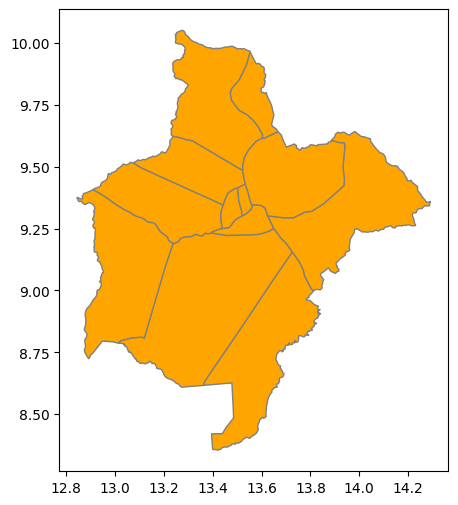

In [11]:
gid2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6, 6), color='orange')

In [12]:
gid2_gdf.NAME_3.unique()


array(['Bachéo', 'Bardanké', 'Bibémi', 'Dembo', 'Demsa', 'Garoua 1',
       'Garoua 2', 'Garoua 3', 'Lagdo', 'Pitoa', 'Tchéboa', 'Touroua'],
      dtype=object)

In [13]:
gid2_gdf.drop(columns=['GID_0','COUNTRY','GID_1','NAME_1','NL_NAME_1','NL_NAME_2','VARNAME_3',
                        'NL_NAME_3','TYPE_3','ENGTYPE_3', 'CC_3', 'HASC_3'], inplace = True)
gid2_gdf.reset_index(drop = True, inplace = True)
gid2_gdf = gid2_gdf[['GID_2', 'NAME_2', 'GID_3', 'NAME_3', 'geometry']]
gid2_gdf.rename(columns = {'GID_2':'GID_2', 'NAME_2':'GID2_NAME', 'GID_3':'GID_3', 'NAME_3':'GID3_NAME'}, inplace = True)

process_latin(gid2_gdf, 'GID2_NAME')
process_latin(gid2_gdf, 'GID3_NAME')

In [14]:
gid2_gdf

,GID_2,GID2_NAME,GID_3,GID3_NAME,geometry
0,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,"POLYGON ((13.55334 9.96373, 13.54918 9.94968, ..."
1,CMR.7.1_1,benoue,CMR.7.1.2_1,bardanke,"POLYGON ((13.44322 9.34539, 13.44182 9.34155, ..."
2,CMR.7.1_1,benoue,CMR.7.1.3_1,bibemi,"POLYGON ((13.64909 9.24992, 13.64764 9.25297, ..."
3,CMR.7.1_1,benoue,CMR.7.1.4_1,dembo,"POLYGON ((13.60365 9.61493, 13.60368 9.61651, ..."
4,CMR.7.1_1,benoue,CMR.7.1.5_1,demsa,"POLYGON ((13.23578 9.62252, 13.23958 9.62175, ..."
5,CMR.7.1_1,benoue,CMR.7.1.6_1,garoua 1,"POLYGON ((13.43791 9.24933, 13.43792 9.24994, ..."
6,CMR.7.1_1,benoue,CMR.7.1.7_1,garoua 2,"POLYGON ((13.50176 9.41480, 13.50505 9.41598, ..."
7,CMR.7.1_1,benoue,CMR.7.1.8_1,garoua 3,"POLYGON ((13.39405 9.23356, 13.39485 9.23399, ..."
8,CMR.7.1_1,benoue,CMR.7.1.9_1,lagdo,"POLYGON ((13.72560 9.15518, 13.72991 9.14901, ..."
9,CMR.7.1_1,benoue,CMR.7.1.10_1,pitoa,"POLYGON ((13.52283 9.48444, 13.52286 9.48652, ..."


In [15]:
gid3_units = gid2_gdf['GID3_NAME'].unique().tolist()

if not os.path.exists(f'../../data/{GID2_NAME}/'):
    os.makedirs(f'../../data/{GID2_NAME}/')

with open(f'../../data/{GID2_NAME}/{GID0}_{GID2_NAME}_SHP_GID3_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in gid3_units:
        f.write("%s\n" % item)

print(f"Number of GID3 Units in {GID2_NAME} (from shapefile): {len(gid3_units)}")

Number of GID3 Units in Benoue (from shapefile): 12


In [16]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, gid2_gdf, col_municipal='GID3_NAME', dimension=3.5)
print(df_grid.shape)

e:\Drive\NOA\MBD-Prediction\NUTS3 Level\Cameroon\notebooks\Benoue\../../../../Modules\utils.py:1181: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()


(824, 5)


In [17]:
df_grid.head()

,geometry,centers,GID3_NAME,x,y
0,"POLYGON ((13.29266 9.64165, 13.29266 9.67309, ...",POINT (13.276717103268211 9.657369255652126),bacheo,13.27672,9.65737
1,"POLYGON ((13.29266 9.67309, 13.29266 9.70453, ...",POINT (13.276717103268211 9.6888109659525),bacheo,13.27672,9.68881
2,"POLYGON ((13.29266 9.70453, 13.29266 9.73597, ...",POINT (13.276717103268211 9.720252676252874),bacheo,13.27672,9.72025
3,"POLYGON ((13.29266 9.73597, 13.29266 9.76742, ...",POINT (13.276717103268211 9.751694386553249),bacheo,13.27672,9.75169
4,"POLYGON ((13.29266 9.86174, 13.29266 9.89318, ...",POINT (13.276717103268211 9.877461227754743),bacheo,13.27672,9.87746


<Axes: >

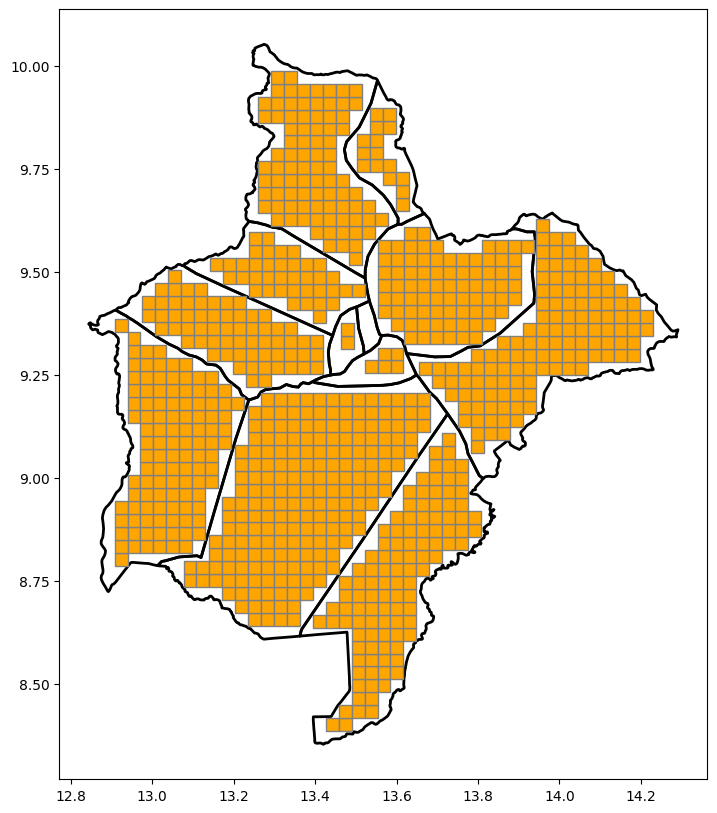

In [18]:
ax = gid2_gdf.plot(figsize=(10, 10), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [19]:
grid_gid3 = df_grid['GID3_NAME'].unique().tolist()
print(f"Number of GID3 Units in Grid: {len(grid_gid3)}")

Number of GID3 Units in Grid: 11


['garoua 2']


C:\Users\dimit\AppData\Local\Temp\ipykernel_14508\1875683160.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_unit["centroid"] = lost_unit["geometry"].centroid
c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\geopandas\geodataframe.py:1525: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


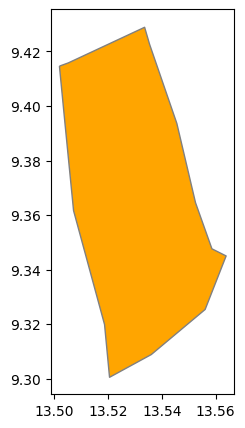

In [ ]:
if (len(gid3_units) != len(grid_gid3)):
    delta = [item for item in gid3_units if item not in grid_gid3]
    print(delta)

    lost_unit = gid2_gdf[gid2_gdf['GID3_NAME'].isin(delta)]
    lost_unit["centroid"] = lost_unit["geometry"].centroid

    add_to_gid2_grid = pd.DataFrame()
    add_to_gid2_grid['geometry'] = lost_unit['geometry']
    add_to_gid2_grid['GID3_NAME'] = lost_unit['GID3_NAME']
    add_to_gid2_grid['x'] = round(lost_unit['centroid'].x, 5)
    add_to_gid2_grid['y'] = round(lost_unit['centroid'].y, 5)

    lost_unit.plot(facecolor="none", edgecolor='grey', figsize=(5, 5), color='orange')

In [24]:
gid2_grid = df_grid.drop(columns=['centers']).copy()

In [27]:
if (len(gid3_units) != len(grid_gid3)):
    gid2_grid = pd.concat([gid2_grid, add_to_gid2_grid], axis=0)

gid2_grid.reset_index(inplace=True, drop=True)

In [29]:
gid2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [30]:
gid2_grid

,shape,GID3_NAME,x,y
0,"POLYGON ((13.29266 9.64165, 13.29266 9.67309, ...",bacheo,13.27672,9.65737
1,"POLYGON ((13.29266 9.67309, 13.29266 9.70453, ...",bacheo,13.27672,9.68881
2,"POLYGON ((13.29266 9.70453, 13.29266 9.73597, ...",bacheo,13.27672,9.72025
3,"POLYGON ((13.29266 9.73597, 13.29266 9.76742, ...",bacheo,13.27672,9.75169
4,"POLYGON ((13.29266 9.86174, 13.29266 9.89318, ...",bacheo,13.27672,9.87746
...,...,...,...,...
820,"POLYGON ((13.19369 9.13297, 13.19369 9.16441, ...",touroua,13.17779,9.14869
821,"POLYGON ((13.19369 9.16441, 13.19369 9.19585, ...",touroua,13.17779,9.18013
822,"POLYGON ((13.19369 9.19585, 13.19369 9.22729, ...",touroua,13.17779,9.21157
823,"POLYGON ((13.22550 9.16441, 13.22550 9.19585, ...",touroua,13.20960,9.18013


In [ ]:
gid2_grid_points = gpd.GeoDataFrame(gid2_grid, geometry=gpd.points_from_xy(gid2_grid.x, gid2_grid.y))

In [32]:
gid2_grid_points.head()

,shape,GID3_NAME,x,y,geometry
0,"POLYGON ((13.29266 9.64165, 13.29266 9.67309, ...",bacheo,13.27672,9.65737,POINT (13.27672 9.65737)
1,"POLYGON ((13.29266 9.67309, 13.29266 9.70453, ...",bacheo,13.27672,9.68881,POINT (13.27672 9.68881)
2,"POLYGON ((13.29266 9.70453, 13.29266 9.73597, ...",bacheo,13.27672,9.72025,POINT (13.27672 9.72025)
3,"POLYGON ((13.29266 9.73597, 13.29266 9.76742, ...",bacheo,13.27672,9.75169,POINT (13.27672 9.75169)
4,"POLYGON ((13.29266 9.86174, 13.29266 9.89318, ...",bacheo,13.27672,9.87746,POINT (13.27672 9.87746)


<Axes: >

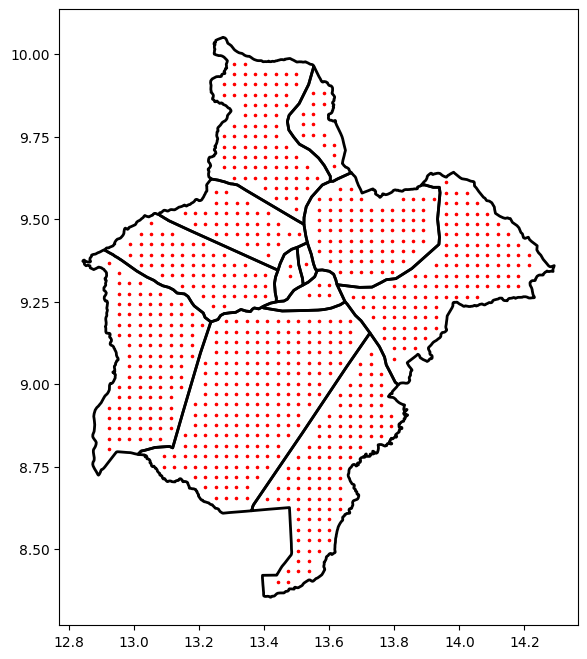

In [34]:
ax = gid2_grid_points.plot(markersize=2.5, figsize=(8, 8), color='red')
gid2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [37]:
final_grid = pd.merge(gid2_grid[['GID3_NAME', 'x', 'y']], gid2_gdf[['GID_2','GID2_NAME','GID_3','GID3_NAME']], how='left', on=['GID3_NAME']) 
final_grid.sort_values(by=['GID3_NAME'], inplace = True)
final_grid = final_grid[['GID_2', 'GID2_NAME', 'GID_3', 'GID3_NAME', 'x', 'y']]

final_grid.reset_index(drop = True, inplace= True)

In [38]:
final_grid

,GID_2,GID2_NAME,GID_3,GID3_NAME,x,y
0,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.27672,9.65737
1,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.43610,9.94034
2,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.43610,9.90890
3,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.43610,9.87746
4,CMR.7.1_1,benoue,CMR.7.1.1_1,bacheo,13.43610,9.84602
...,...,...,...,...,...,...
820,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.98693,9.21157
821,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.98693,9.14869
822,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,12.98693,9.11725
823,CMR.7.1_1,benoue,CMR.7.1.12_1,touroua,13.01874,8.99148


In [39]:
final_grid.GID3_NAME.unique()

array(['bacheo', 'bardanke', 'bibemi', 'dembo', 'demsa', 'garoua 1',
       'garoua 2', 'garoua 3', 'lagdo', 'pitoa', 'tcheboa', 'touroua'],
      dtype=object)

In [40]:
final_grid.to_csv(f'../../data/{GID2_NAME}/{GID0}_{GID2_NAME}_Grid_GID3.csv', encoding=enc, index = False)